In [113]:
# import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings('ignore')

# Get Data

In [114]:
# get data
sheet_name_list = ['Period 1', 'Period 2', 'Period 3']
data_list = []

for sheet_name in sheet_name_list:
    data_period = pd.read_excel('regime_data.xlsx', sheet_name=sheet_name).iloc[1:].copy()
    data_period = data_period.set_index('Unnamed: 0')
    data_period.index.name = 'DATE'
    data_period.columns.name = 'ID'
    data_list.append(data_period)

data_df = pd.concat(data_list, axis=0)
data_df = data_df.sort_index()
data_df

ID,MXCXDMHR Index,LGY7TRUH Index,LUACTRUU Index,LF98TRUU Index,LP05TRUH Index,LP01TRUH Index,BCOMTR Index,M1EF Index,EMUSTRUU Index,MXEF0CX0 Index,USDJPY BGN Curncy,USDCHF BGN Curncy,AUDUSD BGN Curncy,NZDUSD BGN Curncy,USDCAD BGN Curncy,EURUSD BGN Curncy,GBPUSD BGN Curncy,LBUTTRUU Index,SPY US Equity
DATE,,,,,,,,,,,,,,,,,,,
1970-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-05,NaN,NaN,NaN,NaN,NaN,NaN,3.1177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-27,713.99,846.9528,3555.1,2953.53,319.83,649.15,349.6279,894.06,1400.047,1874.5,159.42,0.7855,0.7186,0.5908,1.3627,1.1721,1.3535,378.3391,715.17
2026-04-28,710.84,846.1492,3552.86,2950.28,319.31,648.48,351.6852,886.9,1398.2716,1869.45,159.62,0.7893,0.7181,0.5885,1.3684,1.1712,1.3517,378.3211,711.69
2026-04-29,710.17,844.0966,3538.72,2945.34,318.6,648.07,357.2446,887.76,1396.1287,1866.59,160.41,0.7912,0.7116,0.5829,1.3685,1.1677,1.3475,377.1386,711.58


# Clean Data

In [115]:
# drop nan values
data_df = data_df.dropna()
data_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5994 entries, 2000-12-29 to 2026-05-01
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   MXCXDMHR Index     5994 non-null   object
 1   LGY7TRUH Index     5994 non-null   object
 2   LUACTRUU Index     5994 non-null   object
 3   LF98TRUU Index     5994 non-null   object
 4   LP05TRUH Index     5994 non-null   object
 5   LP01TRUH Index     5994 non-null   object
 6   BCOMTR Index       5994 non-null   object
 7   M1EF Index         5994 non-null   object
 8   EMUSTRUU Index     5994 non-null   object
 9   MXEF0CX0 Index     5994 non-null   object
 10  USDJPY BGN Curncy  5994 non-null   object
 11  USDCHF BGN Curncy  5994 non-null   object
 12  AUDUSD BGN Curncy  5994 non-null   object
 13  NZDUSD BGN Curncy  5994 non-null   object
 14  USDCAD BGN Curncy  5994 non-null   object
 15  EURUSD BGN Curncy  5994 non-null   object
 16  GBPUSD BGN Curncy  5994 

In [116]:
df_prices = data_df.copy()

# set USD as base currency for fx pairs
fx_to_invert = [
    'AUDUSD BGN Curncy', 
    'NZDUSD BGN Curncy', 
    'EURUSD BGN Curncy', 
    'GBPUSD BGN Curncy'
]

for ticker in fx_to_invert:
    if ticker in df_prices.columns:
        df_prices[ticker] = 1.0 / df_prices[ticker]

In [117]:
# compute daily returns
returns_df = df_prices.pct_change()

# initialize dictionary to store values
factor_dict = {}

# single ticker factors
factor_dict['Equity'] = returns_df['MXCXDMHR Index']
factor_dict['Rates'] = returns_df['LGY7TRUH Index']
factor_dict['Commodities'] = returns_df['BCOMTR Index']
factor_dict['Local Inflation'] = returns_df['LBUTTRUU Index']
factor_dict['Local Equity'] = returns_df['SPY US Equity']

# credit factor
credit_tickers = ['LUACTRUU Index', 'LF98TRUU Index', 'LP05TRUH Index', 'LP01TRUH Index']
factor_dict['Credit'] = returns_df[credit_tickers].mean(axis=1)

# EM factor
em_tickers = ['M1EF Index', 'EMUSTRUU Index', 'MXEF0CX0 Index']
factor_dict['Emerging Market'] = returns_df[em_tickers].mean(axis=1)

# fx factirs
fx_tickers = [
    'USDJPY BGN Curncy', 'USDCHF BGN Curncy', 'USDCAD BGN Curncy',
    'AUDUSD BGN Curncy', 'NZDUSD BGN Curncy', 'EURUSD BGN Curncy', 'GBPUSD BGN Curncy'
]
factor_dict['Foreign Currency'] = returns_df[fx_tickers].mean(axis=1)

# create dataframe
factor_returns = pd.DataFrame(factor_dict).dropna(how='all')

# clean up dataframe
factor_returns = factor_returns.replace(0, np.nan).dropna()

factor_returns

,Equity,Rates,Commodities,Local Inflation,Local Equity,Credit,Emerging Market,Foreign Currency
DATE,,,,,,,,
2001-01-31,0.032403,0.015496,-0.023492,0.020870,0.044459,0.051228,0.063786,0.010492
2001-02-28,-0.077436,0.012112,-0.004214,0.016872,-0.095388,0.008158,-0.032326,0.022459
2001-03-30,-0.049290,0.009614,-0.042606,0.009564,-0.058572,-0.014121,-0.040953,0.053337
2001-04-30,0.069221,-0.008446,0.035184,0.005639,0.070443,-0.012992,0.018519,-0.022541
2001-05-31,-0.005534,0.005824,-0.020970,0.011840,0.008326,0.011893,0.011852,0.012790
...,...,...,...,...,...,...,...,...
2026-04-27,0.001641,-0.001750,0.008314,0.000067,0.001723,-0.000459,0.005017,-0.001650
2026-04-28,-0.004412,-0.000949,0.005884,-0.000048,-0.004866,-0.001097,-0.003990,0.002426
2026-04-29,-0.000943,-0.002426,0.015808,-0.003126,-0.000155,-0.002128,-0.000698,0.004612


# Orthogonalization

In [118]:
# function to get 3 year rolling return
def get_pure_factor(target, independent_vars, df, window=756):
    Y = df[target]
    X = sm.add_constant(df[independent_vars])
    
    # Fit the rolling OLS model
    model = RollingOLS(Y, X, window=window).fit()
    
    # Calculate the pure factor (Y - Beta * X)
    betas = model.params.drop(columns=['const'])
    overlapping_risk = (df[independent_vars] * betas).sum(axis=1)
    
    pure_return = Y - overlapping_risk
    return pure_return

In [119]:
# get idiosyncratic risks for core macro (regress against equity and rates)
base_factors = ['Equity', 'Rates']
factor_returns['Credit_Pure'] = get_pure_factor('Credit', base_factors, factor_returns)
factor_returns['Commodities_Pure'] = get_pure_factor('Commodities', base_factors, factor_returns)

# get idiosyncratic risks for secondary macro (regress against all core macro)
all_core_factors = ['Equity', 'Rates', 'Credit_Pure', 'Commodities_Pure']
factor_returns['Emerging_Market_Pure'] = get_pure_factor('Emerging Market', all_core_factors, factor_returns)
factor_returns['Local_Inflation_Pure'] = get_pure_factor('Local Inflation', all_core_factors, factor_returns)
factor_returns['Foreign_Currency_Pure'] = get_pure_factor('Foreign Currency', all_core_factors, factor_returns)
factor_returns['Local_Equity_Pure'] = get_pure_factor('Local Equity', all_core_factors, factor_returns)

# filter for columsn contatining idiosyncratic risk
pure_cols = ['Equity', 'Rates', 'Credit_Pure', 'Commodities_Pure', 
             'Emerging_Market_Pure', 'Local_Inflation_Pure', 'Foreign_Currency_Pure', 'Local_Equity_Pure']

pure_factor_returns = factor_returns[pure_cols].dropna()

pure_factor_returns.head()

,Equity,Rates,Credit_Pure,Commodities_Pure,Emerging_Market_Pure,Local_Inflation_Pure,Foreign_Currency_Pure,Local_Equity_Pure
DATE,,,,,,,,
2001-01-31,0.032403,0.015496,0.051228,-0.023492,0.063786,0.020870,0.010492,0.044459
2001-02-28,-0.077436,0.012112,0.008158,-0.004214,-0.032326,0.016872,0.022459,-0.095388
2001-03-30,-0.049290,0.009614,-0.014121,-0.042606,-0.040953,0.009564,0.053337,-0.058572
2001-04-30,0.069221,-0.008446,-0.012992,0.035184,0.018519,0.005639,-0.022541,0.070443
2001-05-31,-0.005534,0.005824,0.011893,-0.020970,0.011852,0.011840,0.012790,0.008326


# GMM

In [120]:
split_date = '2020-01-01'
train_df = pure_factor_returns.loc[:split_date]
test_df = pure_factor_returns.loc[split_date:]

# get 2D array of features for model
X = train_df.values

X

array([[ 3.24034700e-02,  1.54962732e-02,  5.12283481e-02, ...,
         2.08695383e-02,  1.04916165e-02,  4.44592663e-02],
       [-7.74363621e-02,  1.21124244e-02,  8.15789901e-03, ...,
         1.68717887e-02,  2.24594041e-02, -9.53875347e-02],
       [-4.92901152e-02,  9.61406991e-03, -1.41212834e-02, ...,
         9.56420922e-03,  5.33371778e-02, -5.85720048e-02],
       ...,
       [ 4.66718872e-03,  2.09360901e-03, -4.05002599e-05, ...,
        -1.63236605e-03, -4.78975385e-03, -1.18166161e-03],
       [-5.54966640e-03, -1.70073545e-03,  3.36152648e-04, ...,
         1.53033286e-03, -3.77484511e-03,  2.25341845e-03],
       [ 3.44870830e-04, -2.40552839e-04,  5.31137947e-06, ...,
        -3.17911400e-04, -5.03715427e-03,  1.99874252e-03]],
      shape=(4391, 8))

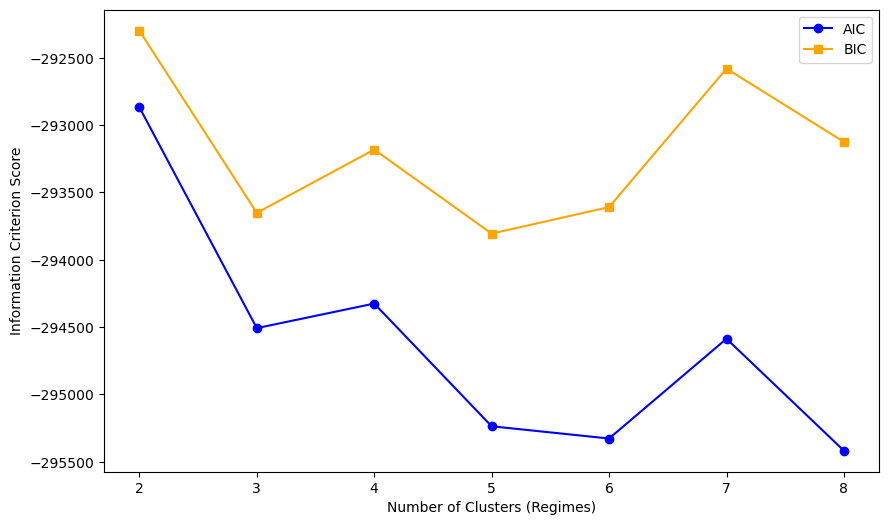

In [121]:
# tune hyperparameters
n_components_range = range(2, 9)

# initialise lists to store evaluation metrics
aic_scores = []
bic_scores = []

# train models and record scores
for n_clusters in n_components_range:
    gmm = GaussianMixture(n_components=n_clusters, 
                          covariance_type='full', 
                          random_state=42)

    gmm.fit(X)
    
    aic_scores.append(gmm.aic(X))
    bic_scores.append(gmm.bic(X))

# plot results
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, aic_scores, label='AIC', marker='o', color='blue')
plt.plot(n_components_range, bic_scores, label='BIC', marker='s', color='orange')

plt.xlabel('Number of Clusters (Regimes)')
plt.ylabel('Information Criterion Score')
plt.legend()
plt.show()

In [122]:
# train model
optimal_clusters = 5

# fit model
final_gmm = GaussianMixture(n_components=optimal_clusters, 
                            covariance_type='full', 
                            random_state=42)

X = train_df.values
final_gmm.fit(X)

regime_predictions = final_gmm.predict(X)

# add regime into dataframe
train_df['Regime'] = regime_predictions

# get metrics
annualized_means = train_df.groupby('Regime').mean() * 252
annualized_vols = train_df.groupby('Regime').std() * np.sqrt(252)

In [123]:
print("\n--- ANNUALIZED MEAN RETURNS BY REGIME ---")
annualized_means.T


--- ANNUALIZED MEAN RETURNS BY REGIME ---


Regime,0,1,2,3,4
Equity,-0.123139,5.155627,-3.799573,-0.962334,0.205954
Rates,0.065406,0.258678,0.114205,0.161672,0.038692
Credit_Pure,0.095252,0.050073,-1.073018,-0.034733,0.059655
Commodities_Pure,0.340959,-1.241083,-1.447015,-0.220113,-0.021712
Emerging_Market_Pure,0.170309,0.939518,-0.179437,0.052397,-0.004387
Local_Inflation_Pure,0.104067,0.703336,-0.069072,0.034871,-0.027504
Foreign_Currency_Pure,-0.080153,-1.220763,1.137065,0.084513,0.022704
Local_Equity_Pure,-0.245516,3.850575,-3.691568,0.077024,0.036871


In [124]:
print("\n--- ANNUALIZED VOLATILITIES BY REGIME ---")
annualized_vols.T


--- ANNUALIZED VOLATILITIES BY REGIME ---


Regime,0,1,2,3,4
Equity,0.187052,0.605849,0.579867,0.300948,0.093604
Rates,0.038802,0.113139,0.103629,0.046467,0.025804
Credit_Pure,0.029978,0.230886,0.183075,0.058878,0.017612
Commodities_Pure,0.155259,0.314845,0.392490,0.272371,0.128487
Emerging_Market_Pure,0.079537,0.295910,0.346630,0.094514,0.043788
Local_Inflation_Pure,0.070468,0.184228,0.134991,0.071893,0.033777
Foreign_Currency_Pure,0.090697,0.172249,0.258355,0.095582,0.058042
Local_Equity_Pure,0.229092,0.409195,0.490413,0.125408,0.052134
